# 03 · Prices and rents (Q3, Q4 preview)

**Question (docs/01 §3, Q3).** What is the price per sq m by area, property type and bedrooms, and how fast is it growing? Also a first look at Q4 (gross yields).

**Definitions.**
- *Median AED per sq m*: the exact median over clean market sales (`is_clean_market_sale`: market sales without C4–C6, C16 or C18 quality flags).
- *Area-weighted AED per sq m*: Σ AED ÷ Σ sq m over clean sales within the class area cap (apartments 1,000 sq m, villas 3,000). It weighs large units more, so it runs above the median for apartments.
- *New rent per sq m*: the median annual rent ÷ sq m over new market rents (`is_market_rent`: new, single-unit contracts, comparable property types, rule C11 applied, with a real area).
- **Min-n**: a segment with fewer than 20 observations shows no value (blank), per docs/01 §7.

Residential apartments and villas / townhouses are the conformed property types 101 and 102. All areas are sq m and all money is AED. **Scope:** 2004 → 2026-09-25; **2026 is partial**.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from dubai_property import config
from dubai_property.analysis import common
from dubai_property.analysis import plotting as P
from dubai_property.analysis import prices_rents as pr

P.apply_style()
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
SNAP = common.snapshot_date()
APT, VILLA = config.RESIDENTIAL_HOMES_KEYS
print("Data snapshot:", SNAP)

Data snapshot: 2026-09-25


## 1. AED per sq m by year: apartments and villas

In [2]:
pp = pr.ppsqm_by_year()
display(
    pp.pivot(
        index="year",
        columns="property_type_label",
        values=["clean_sales", "median_ppsqm_aed", "aw_ppsqm_aed"],
    ).loc[2008:]
)

clean_sales                                  \
property_type_label Residential · Apartment Residential · Villa / Townhouse   
year                                                                          
2008                             10,596.000                       3,700.000   
2009                             42,302.000                       2,426.000   
2010                             22,395.000                       2,212.000   
2011                             16,772.000                       2,069.000   
2012                             20,430.000                       3,021.000   
2013                             36,098.000                       6,349.000   
2014                             30,711.000                       6,082.000   
2015                             22,906.000                       4,975.000   
2016                             22,454.000                       4,605.000   
2017                             26,351.000                       6,352.000   
2018                             19,538.000                       3,365.000   
2019                             22,805.000                       6,564.000   
2020                             19,063.000                       5,679.000   
2021                             34,383.000                      10,284.000   
2022                             60,806.000                      11,339.000   
2023                             91,232.000                      14,112.000   
2024                            132,476.000                      18,064.000   
2025                            162,210.000                      15,220.000   
2026                             91,773.000                       9,402.000   

                           median_ppsqm_aed                                  \
property_type_label Residential · Apartment Residential · Villa / Townhouse   
year                                                                          
2008                              6,674.555                       4,757.220   
2009                              9,017.975                       5,381.960   
2010                              9,709.720                       4,809.705   
2011                              9,144.905                       4,688.690   
2012                              9,846.015                       4,860.410   
2013                             11,125.050                       6,079.120   
2014                             12,932.350                       7,866.185   
2015                             11,906.950                       8,004.060   
2016                             11,805.220                       8,909.480   
2017                             12,470.980                       8,081.625   
2018                             12,585.070                       7,536.540   
2019                             12,977.750                       7,543.540   
2020                             11,314.290                       7,528.350   
2021                             12,474.850                       8,586.315   
2022                             16,237.960                       9,021.410   
2023                             16,433.270                      11,359.325   
2024                             17,631.190                      14,351.880   
2025                             18,656.720                      15,699.605   
2026                             18,567.940                      18,671.775   

                               aw_ppsqm_aed                                  
property_type_label Residential · Apartment Residential · Villa / Townhouse  
year                                                                         
2008                              9,486.930                       5,222.008  
2009                             10,530.376                       5,307.090  
2010                             11,696.641                       4,717.575  
2011                             11,130.985                       4,634.964  
2012    

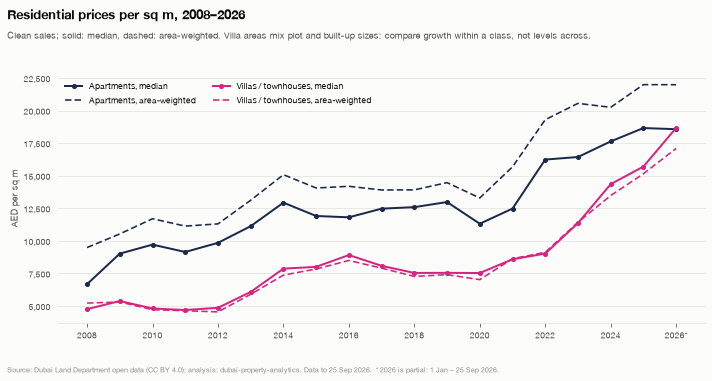

In [3]:
fig, ax = P.figure(size=(10, 5.2))
p = pp[pp["year"] >= 2008]
for key, name, series in [
    (APT, "Apartments", "apartment"),
    (VILLA, "Villas / townhouses", "villa"),
]:
    d = p[p["property_type_key"] == key]
    ax.plot(d["year"], d["median_ppsqm_aed"], color=P.SERIES[series], marker="o", ms=4)
    ax.plot(d["year"], d["aw_ppsqm_aed"], color=P.SERIES[series], ls=(0, (4, 2)), lw=1.6)
    ax.lines[-2].set_label(f"{name}, median")
    ax.lines[-1].set_label(f"{name}, area-weighted")
ax.legend(loc="upper left", ncols=2)
ax.set_ylabel("AED per sq m")
P.count_axis(ax)
P.year_ticks(ax, p["year"], SNAP)
P.titled(
    fig,
    "Residential prices per sq m, 2008–2026",
    "Clean sales; solid: median, dashed: area-weighted. Villa areas mix plot and built-up sizes: compare growth within a class, not levels across.",
)
P.add_source(fig, SNAP)
P.save(fig, "q3_price_per_sqm_apartments_villas")
plt.show()

### Is villa AED per sq m comparable with apartments?

DLD doesn't document whether a villa's `procedure_area` is the plot or the built-up area. The table tests it. Villa sales **with** a bedroom count have built-up-sized areas (a median of about 190–200 sq m). Those **without** one have plot-sized areas (a median of 550–600 sq m). The share without bedrooms fell from about half before 2017 to 10% in 2026, so the villa area basis drifts from plot towards built-up, and that alone lifts villa AED per sq m. Growth is therefore checked two ways that don't depend on the mix: AED per sq m on the bedroom-known subset, and the median price per unit.

In [4]:
basis = pr.area_basis()
display(
    basis[basis["year"].isin([2010, 2015, 2019, 2020, 2023, 2024, 2025, SNAP.year])].set_index(
        ["property_type_key", "year"]
    )
)
b = basis.set_index(["property_type_key", "year"])
for key, name in [(APT, "Apartments"), (VILLA, "Villas")]:
    g_sub = (
        b.loc[(key, 2025), "median_ppsqm_with_bedrooms"]
        / b.loc[(key, 2020), "median_ppsqm_with_bedrooms"]
        - 1
    )
    g_unit = b.loc[(key, 2025), "median_price_aed"] / b.loc[(key, 2020), "median_price_aed"] - 1
    print(
        f"{name} 2020 → 2025: AED/sq m (bedroom-known) {g_sub:+.0%}, median price per unit {g_unit:+.0%}"
    )

clean_sales  share_no_bedrooms  median_area_sqm  \
property_type_key year                                                    
101               2010   22,395.000              0.002           84.450   
                  2015   22,906.000              0.002           82.980   
                  2019   22,805.000              0.001           75.410   
                  2020   19,063.000              0.001           76.930   
                  2023   91,232.000              0.001           76.240   
                  2024  132,476.000              0.002           74.440   
                  2025  162,210.000              0.000           73.640   
                  2026   91,773.000              0.000           71.220   
102               2010    2,212.000              0.490          400.040   
                  2015    4,975.000              0.522          255.000   
                  2019    6,564.000              0.200          230.000   
                  2020    5,679.000              0.263          231.000   
                  2023   14,112.000              0.163          226.820   
                  2024   18,064.000              0.118          221.200   
                  2025   15,220.000              0.121          223.565   
                  2026    9,402.000              0.102          187.920   

                        median_area_with_bedrooms  median_area_no_bedrooms  \
property_type_key year                                                       
101               2010                     84.450                  474.820   
                  2015                     82.780                  308.515   
                  2019                     75.410                  366.550   
                  2020                     76.910                  228.040   
                  2023                     76.220                  275.910   
                  2024                     74.420                  119.220   
                  2025                     73.630                  270.530   
                  2026                     71.210                  199.920   
102               2010                    272.020                  712.535   
                  2015                    216.650                  371.615   
                  2019                    189.640                  432.370   
                  2020                    201.485                  552.760   
                  2023                    191.400                  576.000   
                  2024                    187.920                  570.710   
                  2025                    196.000                  594.580   
                  2026                    175.545                  555.650   

                        median_ppsqm_with_bedrooms  median_price_aed  
property_type_key year                                                
101               2010                   9,709.310       898,573.000  
                  2015                  11,906.950       982,700.000  
                  2019                  12,982.460       971,888.000  
                  2020                  11,316.865       867,525.000  
                  2023                  16,437.200     1,261,858.000  
                  2024                  17,616.200     1,281,730.000  
                  2025                  18,656.440     1,300,000.000  
                  2026                  18,567.640     1,236,509.000  
102               2010                   6,233.400     2,200,000.000  
                  2015                   6,683.100     2,217,300.000  
                  2019                   7,724.920     1,559,500.000  
                  2020                   7,934.275     1,659,888.000  
                  2023                  11,911.210     2,705,388.000  
                  2024                  14,761.490     3,100,000.000  
                  2025                  16,080.000     3,550,000.000  
                  2026                  19,069.440     3,469,

Apartments 2020 → 2025: AED/sq m (bedroom-known) +65%, median price per unit +50%
Villas 2020 → 2025: AED/sq m (bedroom-known) +103%, median price per unit +114%


## 2. By zone

There are 19 market zones (seed_area). Blank cells are below the min-n rule. Years from 2010, because earlier years are thin and distorted by registration timing (notebook 01).

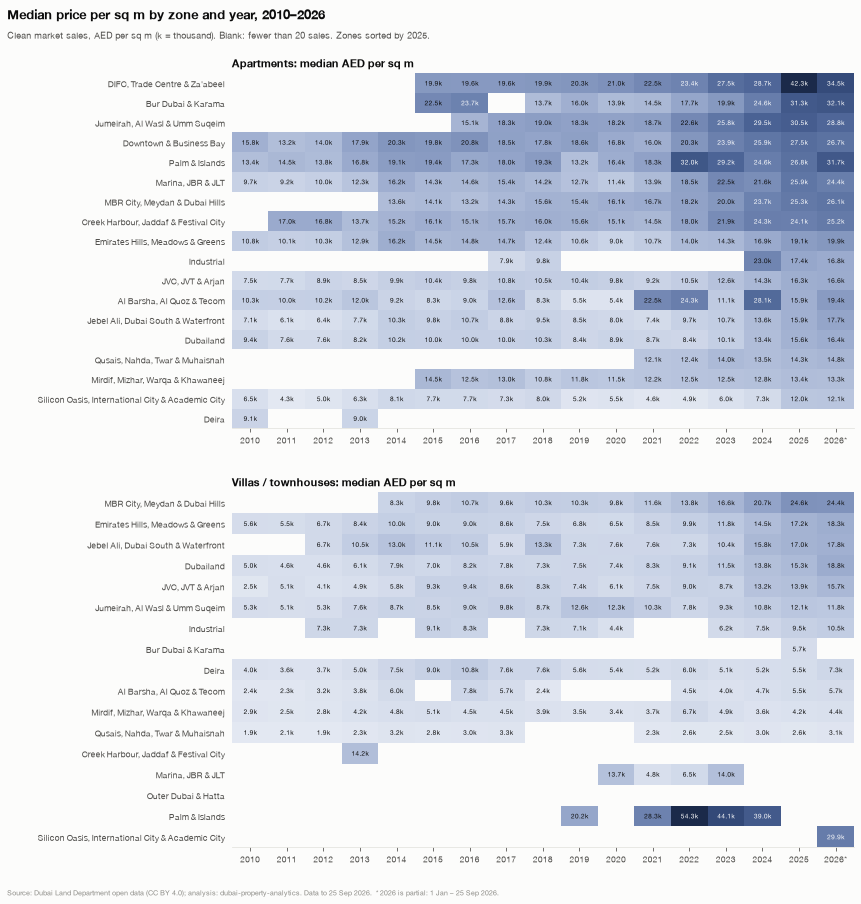

In [5]:
def heatmap(ax, df, value, fmt, title, order=None):
    """Zone × year heatmap on the sequential blue ramp; blank = below min-n."""
    grid = df.pivot(index="zone", columns="year", values=value)
    grid = grid.loc[:, [c for c in grid.columns if c >= 2010]]
    if order is None:
        # Sort by the last complete year (the partial year is thinner and noisier).
        full = [c for c in grid.columns if c < SNAP.year] or list(grid.columns)
        order = grid[full[-1]].sort_values(ascending=False, na_position="last").index
    grid = grid.reindex([z for z in order if z in grid.index])
    ax.imshow(grid.values, aspect="auto", cmap=P.SEQUENTIAL)
    ax.set_xticks(range(grid.shape[1]))
    ax.set_xticklabels([P.year_label(y, SNAP) for y in grid.columns], rotation=0)
    ax.set_yticks(range(grid.shape[0]))
    ax.set_yticklabels(grid.index)
    ax.grid(False)
    vmax = np.nanmax(grid.values)
    for (i, j), v in np.ndenumerate(grid.values):
        if not np.isnan(v):
            ax.text(
                j,
                i,
                fmt(v),
                ha="center",
                va="center",
                fontsize=6.5,
                color="white" if v > 0.55 * vmax else P.TEXT,
            )
    ax.set_title(title)
    return grid


apt_zone = pr.ppsqm_by_zone_year([APT])
villa_zone = pr.ppsqm_by_zone_year([VILLA])
fig, (a1, a2) = P.figure(2, 1, size=(12, 12.5))
fig.subplots_adjust(top=0.92, bottom=0.06, left=0.27, right=0.99, hspace=0.18)
k = lambda v: f"{v / 1000:.1f}k"  # noqa: E731
heatmap(a1, apt_zone, "median_ppsqm_aed", k, "Apartments: median AED per sq m")
heatmap(a2, villa_zone, "median_ppsqm_aed", k, "Villas / townhouses: median AED per sq m")
P.titled(
    fig,
    "Median price per sq m by zone and year, 2010–2026",
    f"Clean market sales, AED per sq m (k = thousand). Blank: fewer than 20 sales. Zones sorted by {SNAP.year - 1}.",
)
P.add_source(fig, SNAP)
P.save(fig, "q3_price_per_sqm_by_zone")
plt.show()

In [6]:
latest, base = SNAP.year - 1, 2019
g = apt_zone.pivot(index="zone", columns="year", values="median_ppsqm_aed")[[base, latest]].dropna()
g["growth"] = g[latest] / g[base] - 1
print(f"Apartments, median AED per sq m, {base} → {latest}:")
display(g.sort_values("growth", ascending=False))

Apartments, median AED per sq m, 2019 → 2025:


year,2019,2025,growth
zone,,,
"Al Barsha, Al Quoz & Tecom","5,499.555","15,918.370",1.894
"Silicon Oasis, International City & Academic City","5,222.220","11,977.625",1.294
"DIFC, Trade Centre & Za'abeel","20,326.255","42,285.100",1.080
"Marina, JBR & JLT","12,687.740","25,929.270",1.044
Palm & Islands,"13,155.610","26,805.430",1.038
Bur Dubai & Karama,"15,966.180","31,317.435",0.961
"Jebel Ali, Dubai South & Waterfront","8,475.690","15,856.430",0.871
Dubailand,"8,351.175","15,558.140",0.863
"Emirates Hills, Meadows & Greens","10,551.490","19,085.340",0.809


## 3. New-contract rent per sq m by zone (residential apartments)

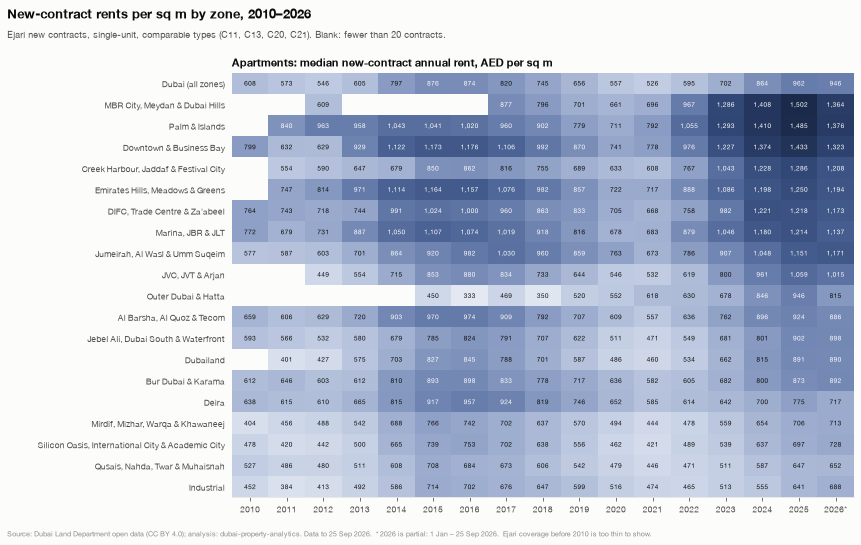

year,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
zone,,,,,,,,,,,,,,,,,
Dubai (all zones),608.200,572.710,545.570,605.490,796.675,876.400,873.845,820.440,744.670,655.740,557.125,526.500,594.830,702.290,863.640,961.760,946.010


In [7]:
rent_zone = pr.rent_ppsqm_by_zone_year([APT])
fig, ax = P.figure(size=(12, 7.5))
fig.subplots_adjust(top=0.88, bottom=0.08, left=0.27, right=0.99)
order = ["Dubai (all zones)"] + list(
    rent_zone[
        (rent_zone["year"] == SNAP.year - 1) & (rent_zone["zone"] != "Dubai (all zones)")
    ].sort_values("median_rent_ppsqm_aed", ascending=False)["zone"]
)
rent_grid = heatmap(
    ax,
    rent_zone,
    "median_rent_ppsqm_aed",
    lambda v: f"{v:,.0f}",
    "Apartments: median new-contract annual rent, AED per sq m",
    order=order,
)
P.titled(
    fig,
    "New-contract rents per sq m by zone, 2010–2026",
    "Ejari new contracts, single-unit, comparable types (C11, C13, C20, C21). Blank: fewer than 20 contracts.",
)
P.add_source(fig, SNAP, note="Ejari coverage before 2010 is too thin to show.")
P.save(fig, "q3_new_rent_per_sqm_by_zone")
plt.show()
display(rent_grid.loc[["Dubai (all zones)"]])

## 4. Top 10 areas by market-sales value, last 12 months

The 12 calendar months to the snapshot month (Oct 2025 – Sep 2026, the last month partial), the same window as `reports/kpi_reconciliation.md` §3. Growth is against the 12 months before.

,area_name,zone,market_sales,market_value_aed,offplan_share_value,prior_value_aed,share_of_dubai_value,value_growth
0,Business Bay,Downtown & Business Bay,"8,259.000","31,710,553,642.000",0.703,"38,253,343,061.000",0.058,-0.171
1,Madinat Al Mataar,"Jebel Ali, Dubai South & Waterfront","16,177.000","25,234,810,244.000",0.792,"24,987,358,889.000",0.046,0.010
2,Al Yelayiss 1,Dubailand,"4,322.000","23,799,009,900.000",0.493,"25,022,471,093.000",0.043,-0.049
3,Hadaeq Sheikh Mohammed Bin Rashid,"MBR City, Meydan & Dubai Hills","2,990.000","18,745,404,875.000",0.205,"21,986,285,609.000",0.034,-0.147
4,Palm Deira,Palm & Islands,"5,016.000","18,713,409,911.000",0.892,"17,238,582,821.000",0.034,0.086
5,Palm Jumeirah,Palm & Islands,"1,301.000","18,610,902,059.000",0.352,"21,751,522,350.000",0.034,-0.144
6,Al Barsha South Fourth,"JVC, JVT & Arjan","12,376.000","16,542,061,594.000",0.550,"23,235,120,240.000",0.030,-0.288
7,Wadi Al Safa 3,Dubailand,"8,129.000","16,338,662,734.000",0.591,"19,356,487,036.000",0.030,-0.156
8,Marsa Dubai,"Marina, JBR & JLT","3,852.000","15,877,696,132.000",0.396,"32,907,039,994.000",0.029,-0.517
9,Jabal Ali First,"Jebel Ali, Dubai South & Waterfront","8,050.000","15,256,029,648.000",0.625,"16,255,376,390.000",0.028,-0.061


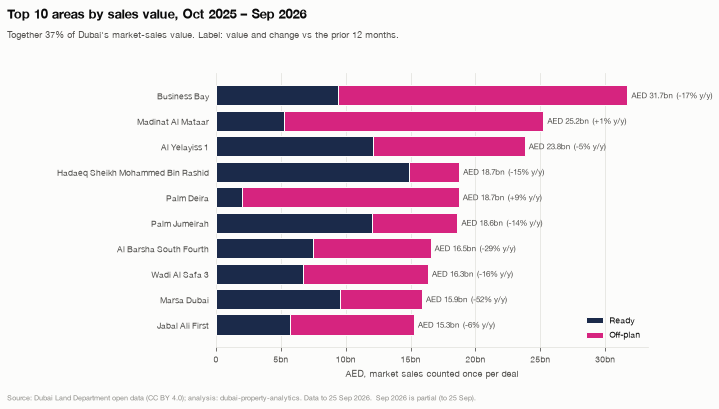

In [8]:
top = pr.top_areas_by_value(SNAP, n=10)
display(top)
fig, ax = P.figure(size=(10, 5.6))
fig.subplots_adjust(left=0.3, top=0.85, right=0.9)
t = top.iloc[::-1]
off = t["market_value_aed"] * t["offplan_share_value"]
ax.barh(
    t["area_name"],
    t["market_value_aed"] - off,
    color=P.SERIES["ready"],
    label="Ready",
    edgecolor=P.SURFACE,
)
ax.barh(
    t["area_name"],
    off,
    left=t["market_value_aed"] - off,
    color=P.SERIES["offplan"],
    label="Off-plan",
    edgecolor=P.SURFACE,
)
for y, (_, r) in enumerate(t.iterrows()):
    ax.text(
        r["market_value_aed"],
        y,
        f"  {P.fmt_aed(r['market_value_aed'])}  ({r['value_growth']:+.0%} y/y)",
        va="center",
        fontsize=8,
        color=P.TEXT_2,
    )
ax.grid(True, axis="x")
ax.grid(False, axis="y")
P.aed_axis(ax, axis="x")
ax.set_xlabel("AED, market sales counted once per deal")
ax.legend(loc="lower right")
P.titled(
    fig,
    "Top 10 areas by sales value, Oct 2025 – Sep 2026",
    f"Together {top['share_of_dubai_value'].sum():.0%} of Dubai's market-sales value. Label: value and change vs the prior 12 months.",
)
P.add_source(fig, SNAP, partial=False, note="Sep 2026 is partial (to 25 Sep).")
P.save(fig, "q3_top10_areas_last12m")
plt.show()

## 5. Mix shift: why the raw median misleads

The raw median AED per sq m of *all* apartment sales changes when **which** apartments sell changes, for example more off-plan units in outer zones. A like-for-like comparison holds the basket fixed. It takes zone × bedroom cells (within apartments) with at least 20 sales in both years, and averages each cell's log change in median AED per sq m, weighted by the earlier year's sales. The gap between the two is the **mix effect**. Function: `prices_rents.like_for_like`.

In [9]:
cells, raw = pr.mix_shift_inputs(APT)
lfl = pr.like_for_like(cells, raw)
display(lfl[lfl["year"] >= 2010].set_index("year"))

,raw_change,lfl_change,mix_effect,cells_used,coverage,median_ppsqm_aed,offplan_share
year,,,,,,,
2010,0.077,0.025,0.052,35,0.990,"9,709.720",0.361
2011,-0.058,-0.142,0.084,33,0.992,"9,144.905",0.110
2012,0.077,0.062,0.015,33,0.984,"9,846.015",0.123
2013,0.130,0.204,-0.074,38,0.989,"11,125.050",0.187
2014,0.162,0.227,-0.065,41,0.969,"12,932.350",0.306
2015,-0.079,-0.036,-0.043,45,0.972,"11,906.950",0.433
2016,-0.009,0.004,-0.012,50,0.955,"11,805.220",0.534
2017,0.056,0.003,0.053,52,0.984,"12,470.980",0.613
2018,0.009,-0.018,0.027,51,0.974,"12,585.070",0.613


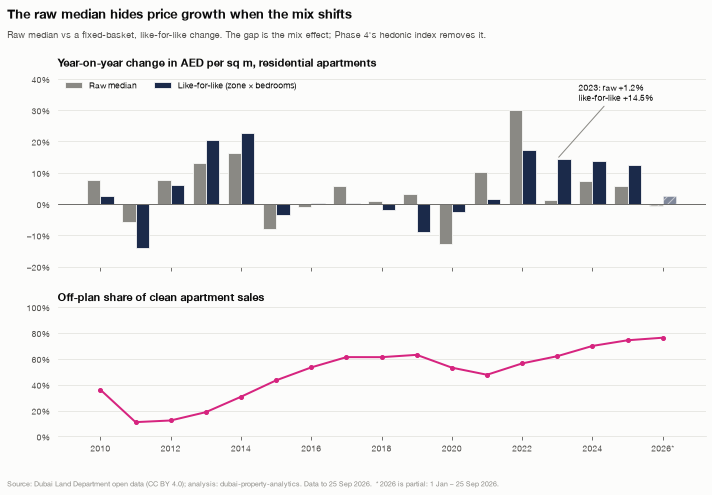

In [10]:
d = lfl[lfl["year"] >= 2010]
ex = d.loc[d["mix_effect"].abs().idxmax()]
fig, (a1, a2) = P.figure(2, 1, size=(10, 6.8), sharex=True, gridspec_kw={"height_ratios": [3, 2]})
fig.subplots_adjust(top=0.86, bottom=0.11, hspace=0.25)
w = 0.38
P.year_bars(
    a1, d["year"], d["raw_change"], SNAP, P.SERIES["neutral"], "Raw median", width=w, offset=-w / 2
)
P.year_bars(
    a1,
    d["year"],
    d["lfl_change"],
    SNAP,
    P.SERIES["total"],
    "Like-for-like (zone × bedrooms)",
    width=w,
    offset=w / 2,
)
a1.axhline(0, color=P.TEXT_2, lw=0.8)
P.pct_axis(a1)
a1.set_title("Year-on-year change in AED per sq m, residential apartments")
a1.set_ylim(-0.2, 0.42)
a1.legend(loc="upper left", ncols=2)
a1.annotate(
    f"{int(ex['year'])}: raw {ex['raw_change']:+.1%}\nlike-for-like {ex['lfl_change']:+.1%}",
    (ex["year"], max(ex["raw_change"], ex["lfl_change"])),
    xytext=(ex["year"] + 0.6, 0.33),
    textcoords="data",
    ha="left",
    fontsize=8.5,
    arrowprops={"arrowstyle": "-", "color": P.MUTED},
)
a2.plot(d["year"], d["offplan_share"], color=P.SERIES["offplan"], marker="o", ms=4)
P.pct_axis(a2)
a2.set_ylim(0, 1)
a2.set_title("Off-plan share of clean apartment sales")
P.year_ticks(a2, d["year"], SNAP)
P.titled(
    fig,
    "The raw median hides price growth when the mix shifts",
    "Raw median vs a fixed-basket, like-for-like change. The gap is the mix effect; Phase 4's hedonic index removes it.",
)
P.add_source(fig, SNAP)
P.save(fig, "q3_mix_shift_example")
plt.show()

In [11]:
# The example year in detail: where apartment sales moved (zone share of clean sales).
y1 = int(ex["year"])
mix = cells[cells["year"].isin([y1 - 1, y1])].groupby(["zone", "year"])["n"].sum().unstack()
mix = mix / mix.sum()
med = cells[cells["year"].isin([y1 - 1, y1])].assign(v=lambda x: x["median_ppsqm_aed"] * x["n"])
med = (
    med.groupby(["zone", "year"])["v"].sum() / med.groupby(["zone", "year"])["n"].sum()
).unstack()
detail = mix.join(med, lsuffix="_share", rsuffix="_ppsqm_wtd").sort_values(
    f"{y1}_share", ascending=False
)
print(
    f"Apartment sales mix, {y1 - 1} vs {y1}: share of clean sales by zone, and the zone's sales-weighted cell median"
)
display(detail.head(10))

Apartment sales mix, 2022 vs 2023: share of clean sales by zone, and the zone's sales-weighted cell median


year,2022_share,2023_share,2022_ppsqm_wtd,2023_ppsqm_wtd
zone,,,,
"JVC, JVT & Arjan",0.139,0.214,"10,635.397","12,634.151"
"MBR City, Meydan & Dubai Hills",0.128,0.146,"18,124.297","19,819.798"
"Marina, JBR & JLT",0.135,0.140,"19,216.522","22,510.679"
Downtown & Business Bay,0.204,0.137,"20,589.381","24,019.005"
Dubailand,0.086,0.124,"8,371.705","10,340.079"
"Creek Harbour, Jaddaf & Festival City",0.074,0.060,"18,165.826","21,709.937"
"Jebel Ali, Dubai South & Waterfront",0.044,0.039,"9,808.680","10,341.313"
"Silicon Oasis, International City & Academic City",0.034,0.032,"4,904.825","6,137.137"
"Jumeirah, Al Wasl & Umm Suqeim",0.063,0.027,"22,903.919","26,298.550"


## 6. Gross yield by zone: **preview, proper yields in Phase 4**

Median annual rent (new market rents) ÷ median price (**ready** clean sales, because an off-plan unit earns no rent yet), over the last 12 months to the snapshot, per zone × class × bedrooms, with at least 20 observations on each side. A zone's figure is the sales-weighted mean of its bedroom cells, and it rolls up to zone × class medians where no bedroom cell passes. Cells outside the docs/04 sanity band (2–15%) are flagged and left out.

Phase 4 computes yields properly (area × sub-type × bedrooms × quarter, with the min-n roll-up) in `agg_yield_quarter`.

In [12]:
yc = pr.yield_preview_cells(SNAP)
yz = pr.yield_by_zone(yc)
print("Cells outside the 2–15% sanity band:")
display(yc[yc["is_outside_sanity"]])
display(yz.sort_values(["property_type_label", "gross_yield"], ascending=[True, False]))

Cells outside the 2–15% sanity band:


,zone,property_type_key,property_type_label,bedrooms,is_rollup,sales_n,median_price_aed,rent_n,median_annual_rent_aed,gross_yield,is_outside_sanity
3,"Al Barsha, Al Quoz & Tecom",101,Residential · Apartment,3.000,False,97,"662,500.000",321,"134,000.000",0.202,True


,zone,property_type_label,gross_yield,method,sales_n,rent_n,cells_flagged
32,"Silicon Oasis, International City & Academic City",Residential · Apartment,0.098,bedroom cells,1936,18594,0
13,Industrial,Residential · Apartment,0.088,bedroom cells,173,4577,0
17,"Jebel Ali, Dubai South & Waterfront",Residential · Apartment,0.079,bedroom cells,2742,14157,0
0,"Al Barsha, Al Quoz & Tecom",Residential · Apartment,0.075,bedroom cells,454,7036,1
9,Dubailand,Residential · Apartment,0.075,bedroom cells,7156,22037,0
15,"JVC, JVT & Arjan",Residential · Apartment,0.073,bedroom cells,6092,27644,0
11,"Emirates Hills, Meadows & Greens",Residential · Apartment,0.062,bedroom cells,457,1758,0
21,"MBR City, Meydan & Dubai Hills",Residential · Apartment,0.062,bedroom cells,3053,13275,0
8,Downtown & Business Bay,Residential · Apartment,0.058,bedroom cells,3810,16189,0
23,"Marina, JBR & JLT",Residential · Apartment,0.058,bedroom cells,3497,15129,0


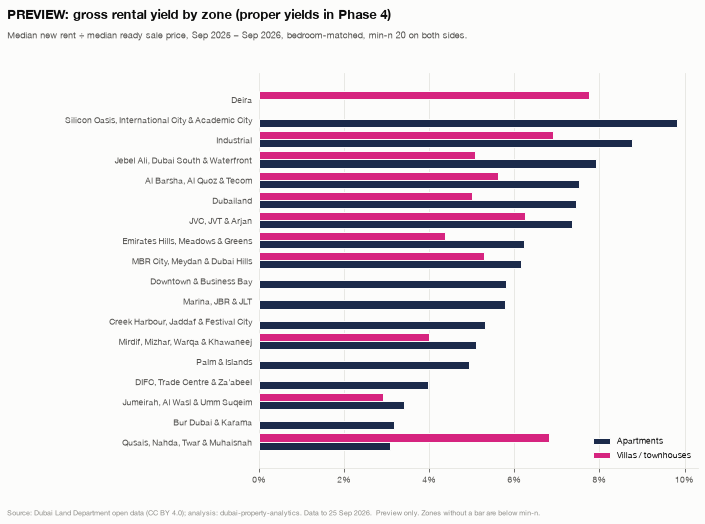

In [13]:
yz_ = yz.dropna(subset=["gross_yield"])
order = (
    yz_[yz_["property_type_label"].str.contains("Apartment")]
    .sort_values("gross_yield")["zone"]
    .tolist()
)
order += [z for z in yz_["zone"].unique() if z not in order]
fig, ax = P.figure(size=(10, 7.2))
fig.subplots_adjust(left=0.36, top=0.87, bottom=0.1, right=0.97)
h = 0.4
for i, (label, series, off) in enumerate(
    [("Apartment", "apartment", -h / 2), ("Villa", "villa", h / 2)]
):
    s = yz_[yz_["property_type_label"].str.contains(label)].set_index("zone").reindex(order)
    ypos = np.arange(len(order)) + off
    ax.barh(
        ypos,
        s["gross_yield"],
        height=h,
        color=P.SERIES[series],
        label="Apartments" if i == 0 else "Villas / townhouses",
        edgecolor=P.SURFACE,
    )
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order)
ax.grid(True, axis="x")
ax.grid(False, axis="y")
P.pct_axis(ax, axis="x")
ax.legend(loc="lower right")
P.titled(
    fig,
    "PREVIEW: gross rental yield by zone (proper yields in Phase 4)",
    "Median new rent ÷ median ready sale price, Sep 2025 – Sep 2026, bedroom-matched, min-n 20 on both sides.",
)
P.add_source(fig, SNAP, partial=False, note="Preview only. Zones without a bar are below min-n.")
P.save(fig, "q4_gross_yield_preview_by_zone")
plt.show()

## Findings

1. **Villa prices roughly doubled from 2020 to 2025, apartments rose about 65%.** Apartment AED per sq m went from 11,314 to 18,657 (+65%; +50% per unit). For villas, AED per sq m on sales with a bedroom count (built-up-like areas) went from 7,934 to 16,080 (+103%), and the median price per unit from AED 1.66m to 3.55m (+114%). **Villa and apartment levels per sq m are not comparable.** Villa `procedure_area` mixes built-up areas (sales with bedrooms, median ~190–200 sq m) with plot-like areas (sales without bedrooms, median 550–600 sq m; 50% of villa sales before 2017, 10% in 2026), so the all-villa median per sq m drifts up as the mix moves. It should not be compared with apartments.
2. **Zone growth ranges from +13% to +108%.** The median apartment price per sq m from 2019 to 2025 rose +108% in DIFC, Trade Centre & Za'abeel (to AED 42,285), +104% in Marina, JBR & JLT and +104% in Palm & Islands, but only +13% in Mirdif, Mizhar, Warqa & Khawaneej. The +189% in Al Barsha, Al Quoz & Tecom is mostly mix: that zone blends Tecom towers with Al Quoz.
3. **New rents rose faster than prices from the 2021 low.** The Dubai-wide median new apartment rent went from AED 526 per sq m a year (2021) to 962 (2025), +83%. The highest in 2025 were MBR City, Meydan & Dubai Hills (1,502), Palm & Islands (1,485) and Downtown & Business Bay (1,433).
4. **Sales value is concentrated and mostly off-plan.** Over Oct 2025 – Sep 2026 the top 10 areas took 37% of market-sales value. Business Bay leads with AED 31.7bn (70% off-plan), followed by Madinat Al Mataar with AED 25.2bn (79% off-plan).
5. **The raw median understated 2023–25 growth.** In 2023 the raw apartment median rose 1.2%, but like-for-like (zone × bedrooms) it rose 14.5%. Sales shifted to cheaper zones: JVC, JVT & Arjan went from 13.9% to 21.4% of apartment sales, and Downtown & Business Bay fell from 20.4% to 13.7%. 2024 (+7.3% raw vs +13.6%) and 2025 (+5.8% vs +12.4%) point the same way; 2022 ran the other way (+30.2% vs +17.4%). **Phase 4 implication:** a raw median confounds composition with price, so the price index must be hedonic (time dummies with location and unit controls), not a median.
6. **Gross yield preview (proper yields in Phase 4).** Apartment gross yields range from 3.1–3.4% in the older and prime zones (Qusais roll-up, Bur Dubai & Karama, Jumeirah) to 7.3–9.8% in outer and value zones (JVC, Dubailand, Jebel Ali / Dubai South, Silicon Oasis). Villa yields run from 2.9% (Jumeirah) to 7.8% (Deira, roll-up). 5 zone × class segments are below min-n, and 1 bedroom cell (Al Barsha 3-bed, 20%) is outside the 2–15% sanity band and left out.